In [6]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, confusion_matrix, recall_score
from sklearn.ensemble import RandomForestRegressor

In [8]:
import requests
import pandas as pd

url = "https://fantasy.premierleague.com/api/bootstrap-static/"
response = requests.get(url)
raw = response.json()

data = pd.DataFrame(raw['elements'])

teams_df = pd.DataFrame(raw['teams'])
team_map = dict(zip(teams_df['id'], teams_df['name']))

position_map = {1: 'GKP', 2: 'DEF', 3: 'MID', 4: 'FWD'}

data['player_name'] = data['first_name'] + ' ' + data['second_name']
data['position_name'] = data['element_type'].map(position_map)
data['club_name'] = data['team'].map(team_map)

for col in ['influence', 'creativity', 'threat', 'ict_index',
            'expected_goals', 'expected_assists', 'expected_goal_involvements',
            'expected_goals_conceded', 'expected_goals_per_90',
            'expected_assists_per_90', 'expected_goal_involvements_per_90',
            'expected_goals_conceded_per_90', 'form', 'points_per_game']:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0)

print(f"Data loaded: {data.shape[0]} players, {data.shape[1]} columns")
print(f"Positions: {data['position_name'].value_counts().to_dict()}")

data.to_csv("fpl_data.csv", index=False)
print(f"Saved {len(data)} players to fpl_data.csv")

Data loaded: 840 players, 108 columns
Positions: {'MID': 379, 'DEF': 270, 'GKP': 97, 'FWD': 94}
Saved 840 players to fpl_data.csv


In [9]:

base_cols = ['player_name', 'position_name', 'club_name']

GK_attribut_total = ['goals_conceded', 'minutes', 'clean_sheets',
                     'own_goals', 'penalties_saved', 'saves', 'expected_goals_conceded']
GK_attribut_match = ['saves_per_90', 'expected_goals_conceded_per_90',
                     'goals_conceded_per_90', 'clean_sheets_per_90', 'starts_per_90']

DF_attribut_total = ['minutes', 'clean_sheets', 'goals_conceded', 'own_goals', 'expected_goals_conceded', 'tackles', 'clearances_blocks_interceptions',
                     'defensive_contribution', 'influence']
DF_attribut_match = ['defensive_contribution_per_90',
                     'expected_goals_conceded_per_90', 'goals_conceded_per_90', 'starts_per_90', 'clean_sheets_per_90']

MF_attribut_total = ['assists', 'creativity',
                     'minutes', 'expected_goal_involvements', 'expected_assists', 'influence']
MF_attribut_match = ['expected_goal_involvements_per_90',
                     'expected_assists_per_90']

FWD_attribut_total = ['goals_scored', 'expected_goals',
                      'expected_goal_involvements', 'threat', 'minutes']
FWD_attribut_match = ['expected_goals_per_90',
                      'expected_goal_involvements_per_90', 'starts_per_90']



filter_gk = data[data['position_name'] == 'GKP']
GK_stat = filter_gk[base_cols + GK_attribut_total + GK_attribut_match].copy()

filter_DF = data[data['position_name'] == 'DEF']
Def_stat = filter_DF[base_cols + DF_attribut_total + DF_attribut_match].copy()

filter_mf = data[data['position_name'] == 'MID']
MF_stat = filter_mf[base_cols + MF_attribut_total + MF_attribut_match].copy()

filter_FWD = data[data['position_name'] == 'FWD']
FWD_stat = filter_FWD[base_cols +
                      FWD_attribut_total + FWD_attribut_match].copy()

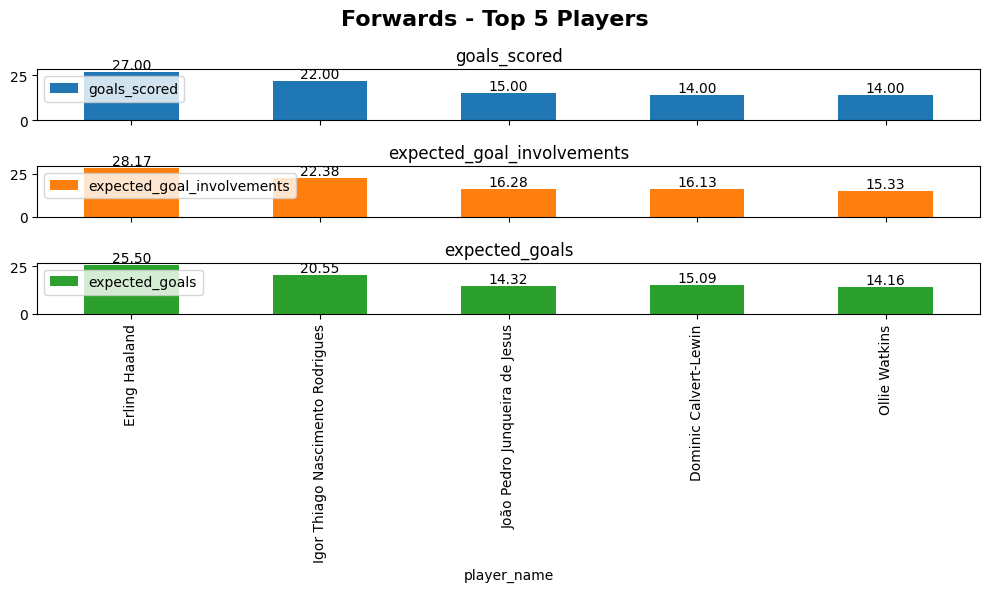

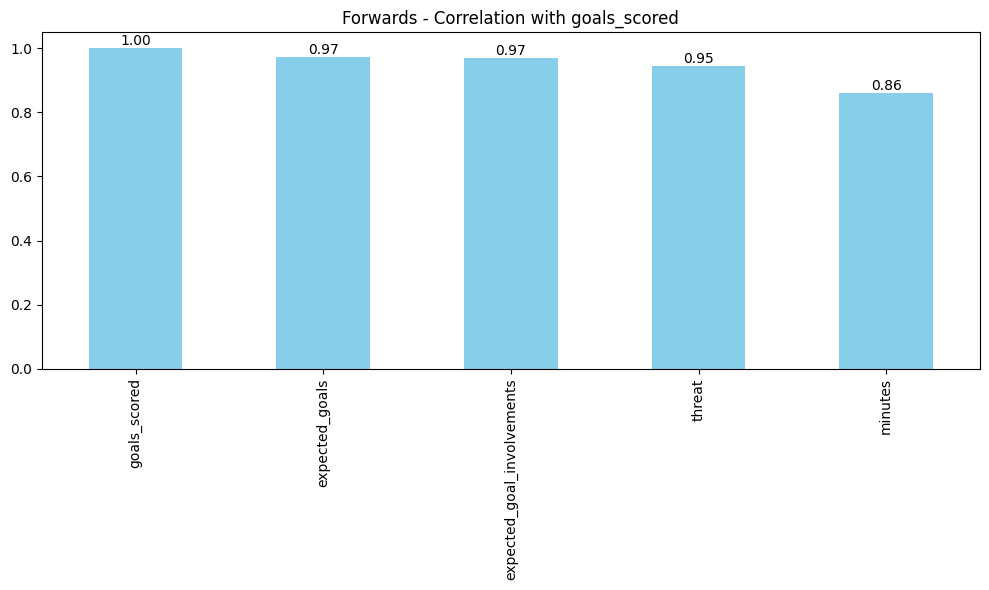

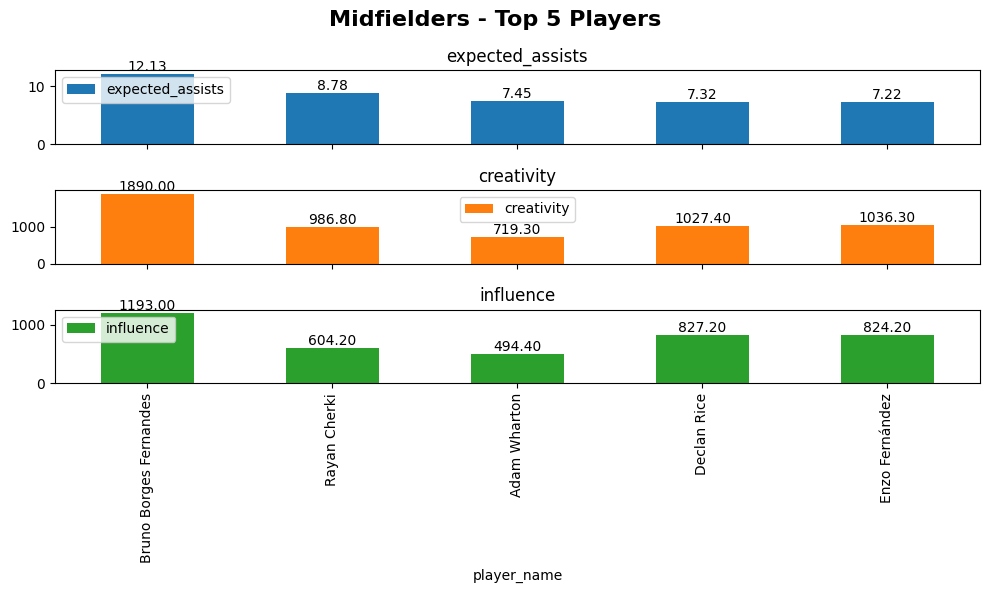

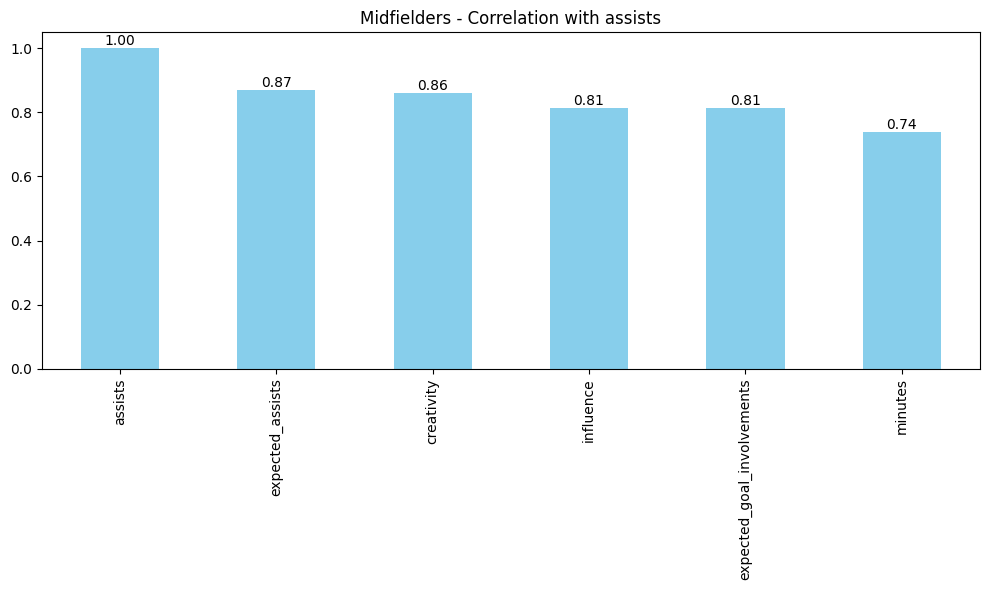

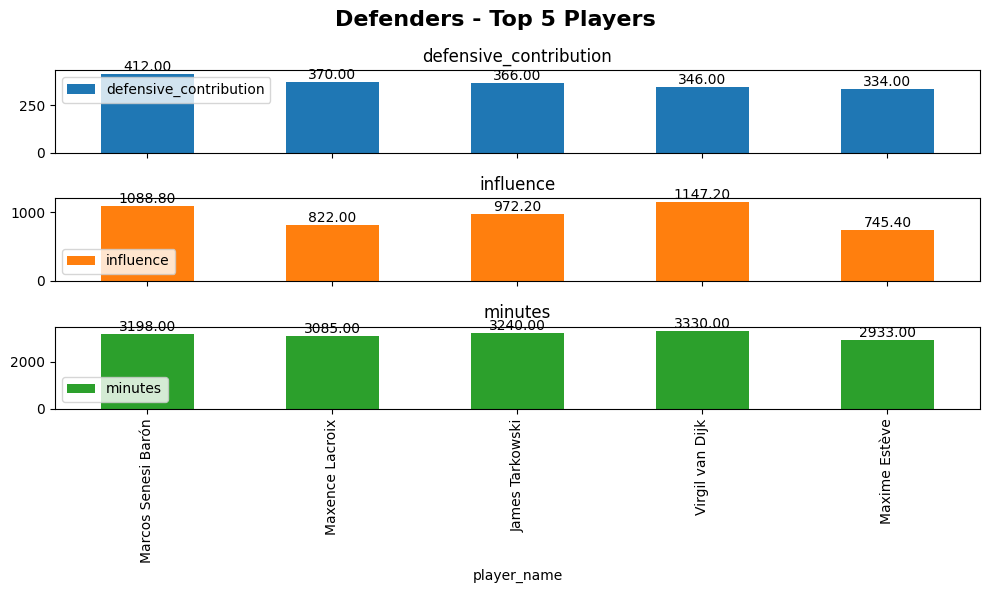

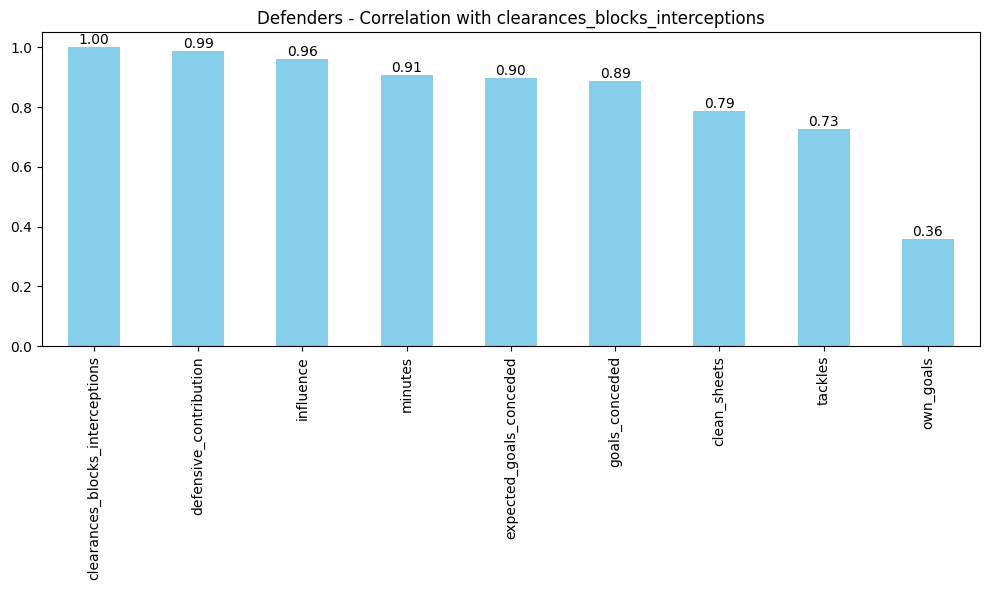

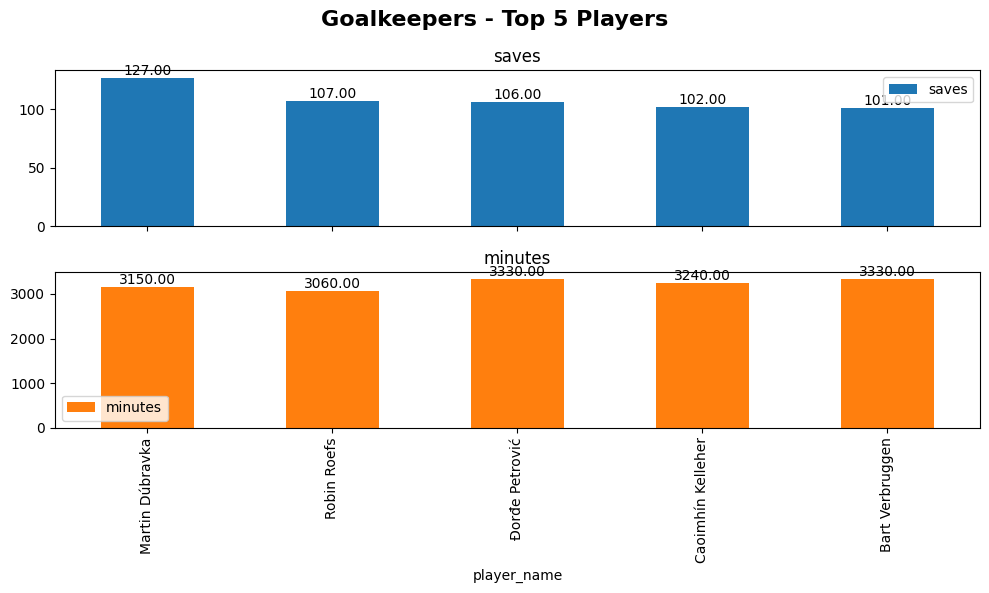

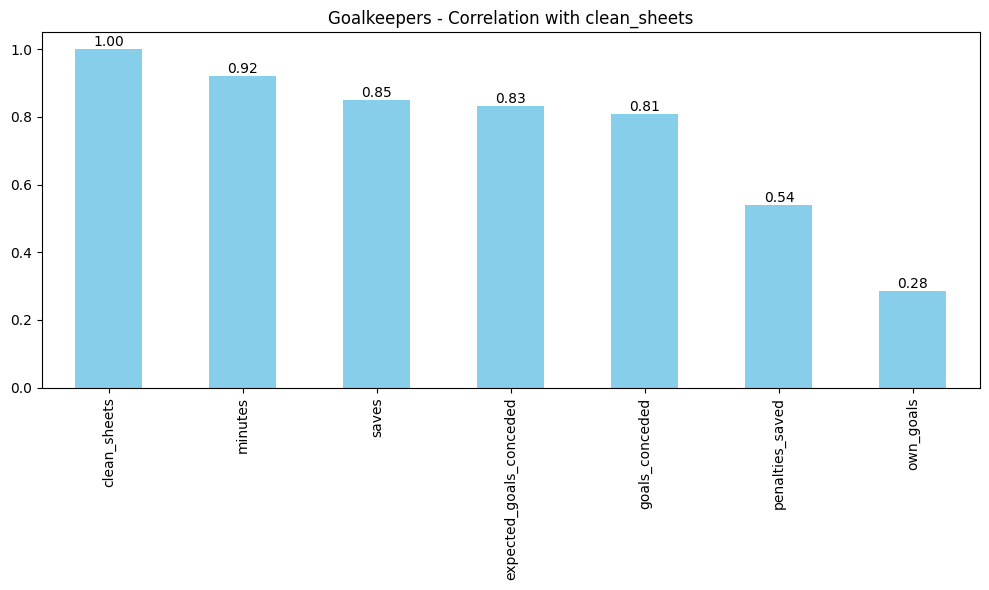

In [10]:
def rank_and_correlate(df, metrics, title, total_attr, match_attr, corr_target):


    df_copy = df.copy()

    regular_starters = df_copy[df_copy['minutes'] > df_copy['minutes'].min()]

    rank_save = regular_starters.nlargest(5, metrics)
    rank_save = rank_save.drop_duplicates(subset=['player_name'])
    rank_data = rank_save[['player_name'] + metrics]

    plot_ax = rank_data.set_index('player_name').plot(
        kind='bar', subplots=True, figsize=(10, 6))

    for i in range(len(metrics)):
        plot_ax[i].bar_label(plot_ax[i].containers[0], fmt='%.2f')

    fig = plot_ax[0].get_figure()
    fig.suptitle(f"{title} - Top 5 Players", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    multi_columns = []
    for col in df_copy.columns:
        if col in base_cols:
            multi_columns.append(('player_info', col))
        elif col in total_attr:
            multi_columns.append(('total_atribut', col))
        elif col in match_attr:
            multi_columns.append(('Match_atribut', col))
        else:
            multi_columns.append(('Other', col))

    df_copy.columns = pd.MultiIndex.from_tuples(multi_columns)

    correlation_matrix = df_copy.loc[:, 'total_atribut'].corr()

    target = correlation_matrix[corr_target]
    target_sorted = target.abs().sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    ax = target_sorted.plot(kind='bar', color='skyblue')

    plt.title(f"{title} - Correlation with {corr_target}")

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

    plt.tight_layout()

rank_and_correlate(FWD_stat, ['goals_scored', 'expected_goal_involvements', 'expected_goals'], 'Forwards',
                   FWD_attribut_total, FWD_attribut_match, 'goals_scored')

rank_and_correlate(MF_stat, ['expected_assists', 'creativity', 'influence'], 'Midfielders',
                   MF_attribut_total, MF_attribut_match, 'assists')

rank_and_correlate(Def_stat, ['defensive_contribution', 'influence',
                              'minutes'], 'Defenders',
                   DF_attribut_total, DF_attribut_match, 'clearances_blocks_interceptions')

rank_and_correlate(GK_stat, ['saves', 'minutes'], 'Goalkeepers',
                   GK_attribut_total, GK_attribut_match, 'clean_sheets')

                   Model  Accuracy (Test)  Accuracy (Train)  Precision   Recall  F1-Score  ROC-AUC
      Random Forest (RF)         0.921053          1.000000   0.666667 0.666667  0.666667 0.838308
Logistic Regression (LR)         0.907895          0.927393   0.625000 0.555556  0.588235 0.946932
       DecisionTree (DT)         0.934211          1.000000   0.750000 0.666667  0.705882 0.818408
       Kneighbours (knn)         0.907895          0.947195   0.600000 0.666667  0.631579 0.800166
               SV (SVM)          0.894737          0.930693   0.571429 0.444444  0.500000 0.747927


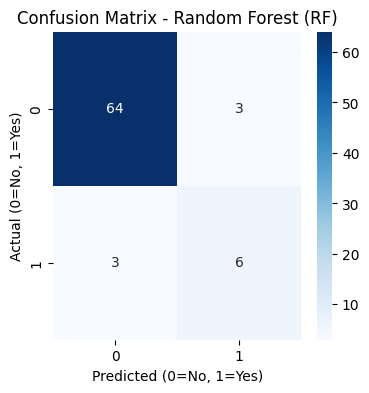

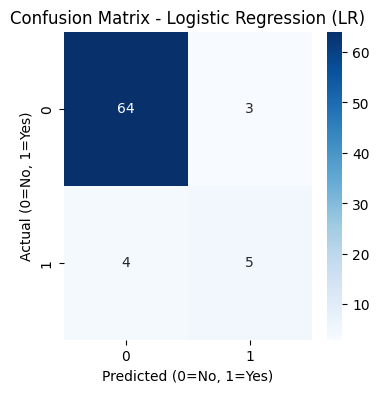

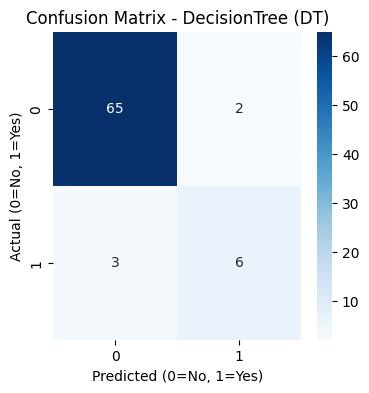

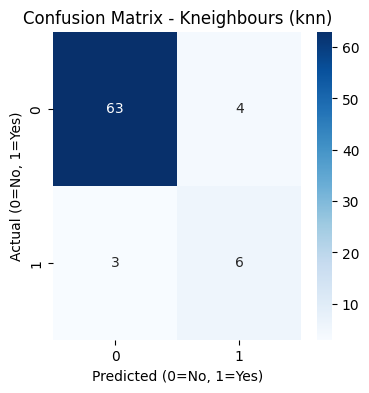

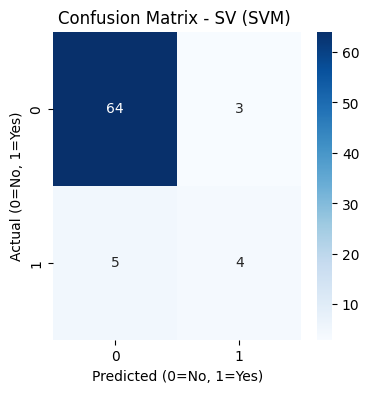

                   Model  Accuracy (Test)  Accuracy (Train)  Precision  Recall  F1-Score  ROC-AUC
      Random Forest (RF)         0.842105          1.000000   0.250000     1.0       0.4 1.000000
Logistic Regression (LR)         0.894737          0.960000   0.333333     1.0       0.5 1.000000
       DecisionTree (DT)         0.842105          1.000000   0.250000     1.0       0.4 0.916667
       Kneighbours (knn)         0.894737          0.946667   0.333333     1.0       0.5 0.944444
               SV (SVM)          0.894737          0.960000   0.333333     1.0       0.5 1.000000


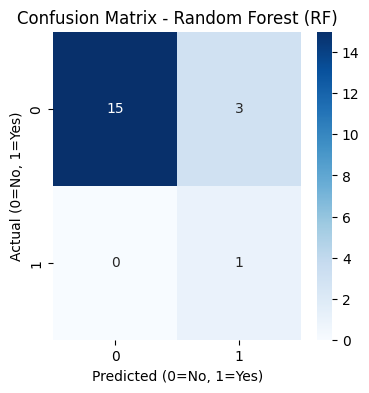

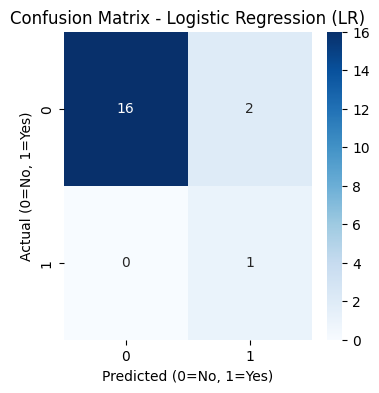

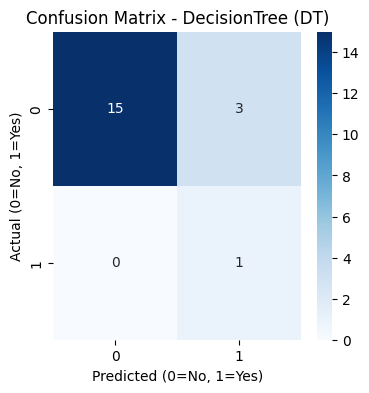

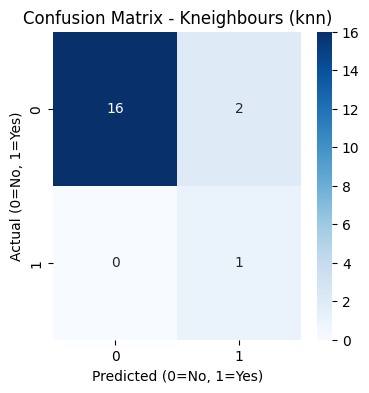

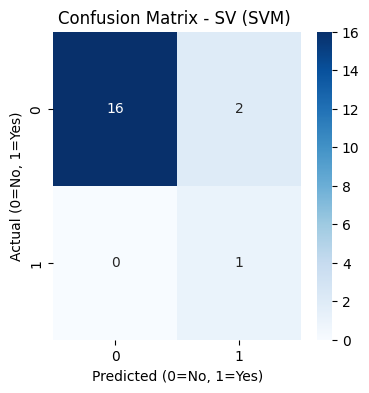

                   Model  Accuracy (Test)  Accuracy (Train)  Precision  Recall  F1-Score  ROC-AUC
      Random Forest (RF)              1.0          1.000000        1.0     1.0       1.0      1.0
Logistic Regression (LR)              1.0          0.967593        1.0     1.0       1.0      1.0
       DecisionTree (DT)              1.0          1.000000        1.0     1.0       1.0      1.0
       Kneighbours (knn)              1.0          0.962963        1.0     1.0       1.0      1.0
               SV (SVM)               1.0          0.967593        1.0     1.0       1.0      1.0


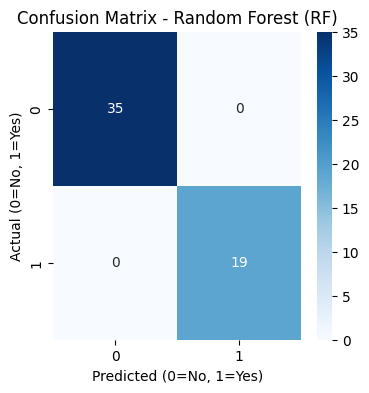

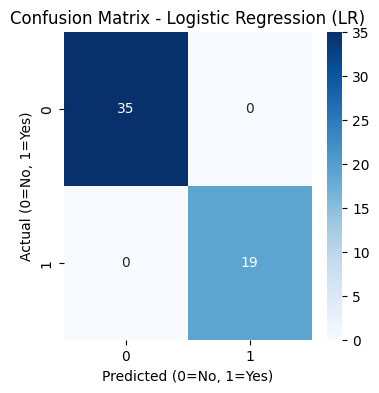

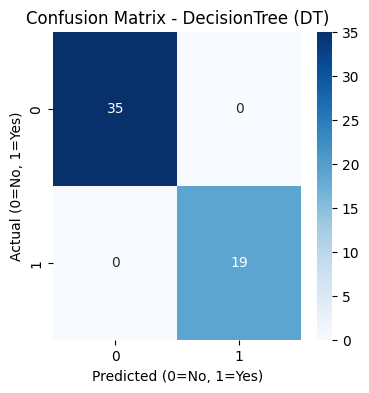

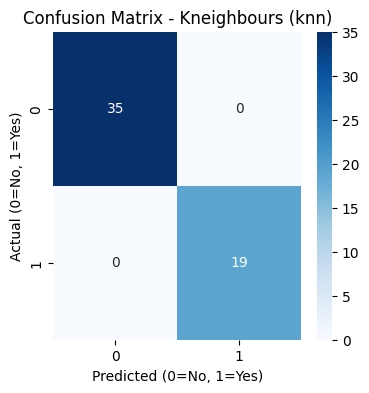

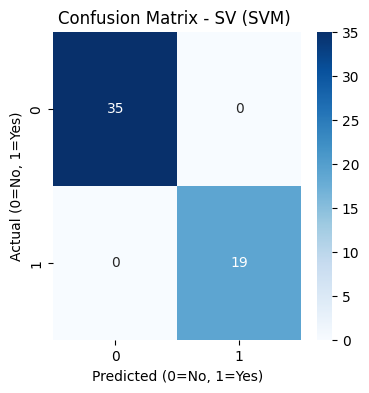

                   Model  Accuracy (Test)  Accuracy (Train)  Precision  Recall  F1-Score  ROC-AUC
      Random Forest (RF)             1.00               1.0        1.0   1.000  1.000000      1.0
Logistic Regression (LR)             0.95               1.0        1.0   0.875  0.933333      1.0
       DecisionTree (DT)             1.00               1.0        1.0   1.000  1.000000      1.0
       Kneighbours (knn)             1.00               1.0        1.0   1.000  1.000000      1.0
               SV (SVM)              1.00               1.0        1.0   1.000  1.000000      1.0


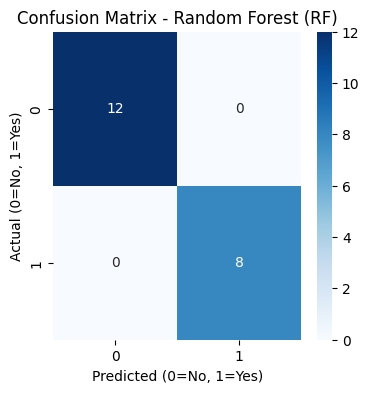

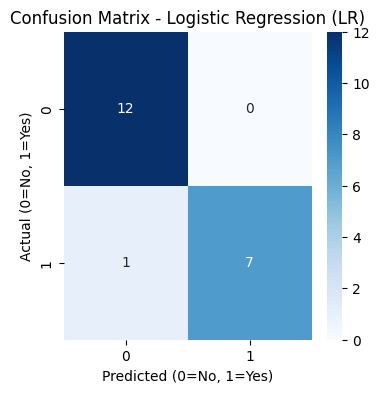

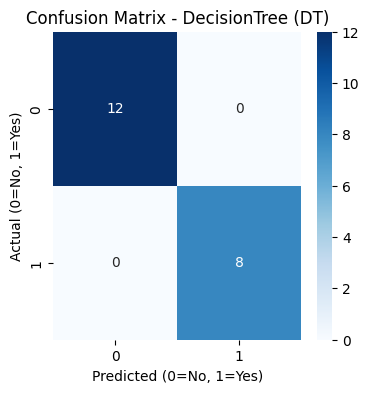

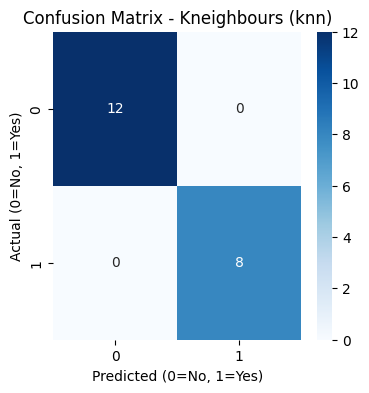

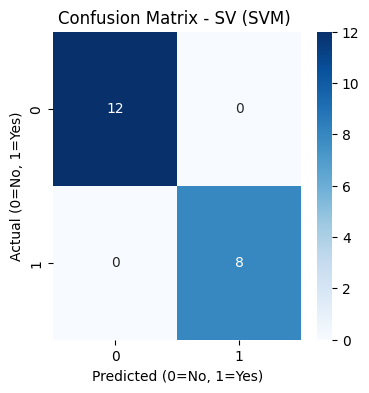

In [11]:
def classify_elite_players(df, features, target_col, threshold, title_name):

    X = df[features]

    y_binary = (df[target_col] >= threshold).astype(int)

    x_train, x_test, y_train, y_test = train_test_split(
        X, y_binary, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    rf = RandomForestClassifier(random_state=42).fit(x_train, y_train)
    lr = LogisticRegression(
        max_iter=1000, random_state=42).fit(x_train, y_train)
    dt = DecisionTreeClassifier(random_state=42).fit(x_train, y_train)
    knn = KNeighborsClassifier().fit(x_train, y_train)
    svm = SVC(probability=True, random_state=42).fit(x_train, y_train)


    def evaluate_model(model, x_train, y_train, x_test, y_test):
        y_train_pred = model.predict(x_train)
        y_test_pred = model.predict(x_test)
        cm = confusion_matrix(y_test, y_test_pred)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(x_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_prob)
        else:
            roc_auc = None

        result = {
            'Accuracy (Train)': accuracy_score(y_train, y_train_pred),
            'Accuracy (Test)': accuracy_score(y_test, y_test_pred),
            'Precision': precision_score(y_test, y_test_pred, zero_division=0),
            'Recall': recall_score(y_test, y_test_pred, zero_division=0),
            'F1-Score': f1_score(y_test, y_test_pred, zero_division=0),
            'ROC-AUC': roc_auc,
            'Confusion Matrix': cm
        }
        return result

    results = {
        'Random Forest (RF)': evaluate_model(rf, x_train, y_train, x_test, y_test),
        'Logistic Regression (LR)': evaluate_model(lr, x_train, y_train, x_test, y_test),
        'DecisionTree (DT)': evaluate_model(dt, x_train, y_train, x_test, y_test),
        'Kneighbours (knn)': evaluate_model(knn, x_train, y_train, x_test, y_test),
        'SV (SVM) ': evaluate_model(svm, x_train, y_train, x_test, y_test)

    }

    rows = []
    for model_name, metrics in results.items():
        rows.append({
            'Model': model_name,
            'Accuracy (Test)': metrics['Accuracy (Test)'],
            'Accuracy (Train)': metrics['Accuracy (Train)'],
            'Precision': metrics['Precision'],
            'Recall': metrics['Recall'],
            'F1-Score': metrics['F1-Score'],
            'ROC-AUC': metrics['ROC-AUC']
        })

    summary = pd.DataFrame(rows)
    print(summary.to_string(index=False))

    for model_name, metrics in results.items():
        plt.figure(figsize=(4, 4))
        sns.heatmap(metrics['Confusion Matrix'],
                    annot=True, fmt='d', cmap='Blues')
        plt.title(f"Confusion Matrix - {model_name}")
        plt.xlabel("Predicted (0=No, 1=Yes)")
        plt.ylabel("Actual (0=No, 1=Yes)")
        plt.show()



classify_elite_players(
    df=MF_stat,
    features=['expected_assists', 'creativity', 'influence'],
    target_col='assists',
    threshold=5,
    title_name='Midfielders'
)

classify_elite_players(
    df=FWD_stat,
    features=['expected_goals', 'threat', 'expected_goal_involvements'],
    target_col='goals_scored',
    threshold=10,
    title_name='Forwards'
)

classify_elite_players(
    df=Def_stat,
    features=['defensive_contribution', 'influence',
              'minutes'],
    target_col='clearances_blocks_interceptions',
    threshold=75,
    title_name='Defender'
)

classify_elite_players(
    df=GK_stat,
    features=['saves', 'minutes'],
    target_col='saves',
    threshold=50,
    title_name='Goalkeeper'
)



End of Season Forecast: Midfielders - Assists
----------------------------------------------------------------------
           Player Name  Current Assists  ML Rate (Per Game)  Predicted Next 8 Games  PREDICTED FINAL TOTAL
Bruno Borges Fernandes               23                0.32                    2.54                     26
          Rayan Cherki               13                0.54                    4.32                     17
          Adam Wharton                6                0.21                    1.69                      8
           Declan Rice                9                0.18                    1.42                     10
        Enzo Fernández                5                0.18                    1.42                      6


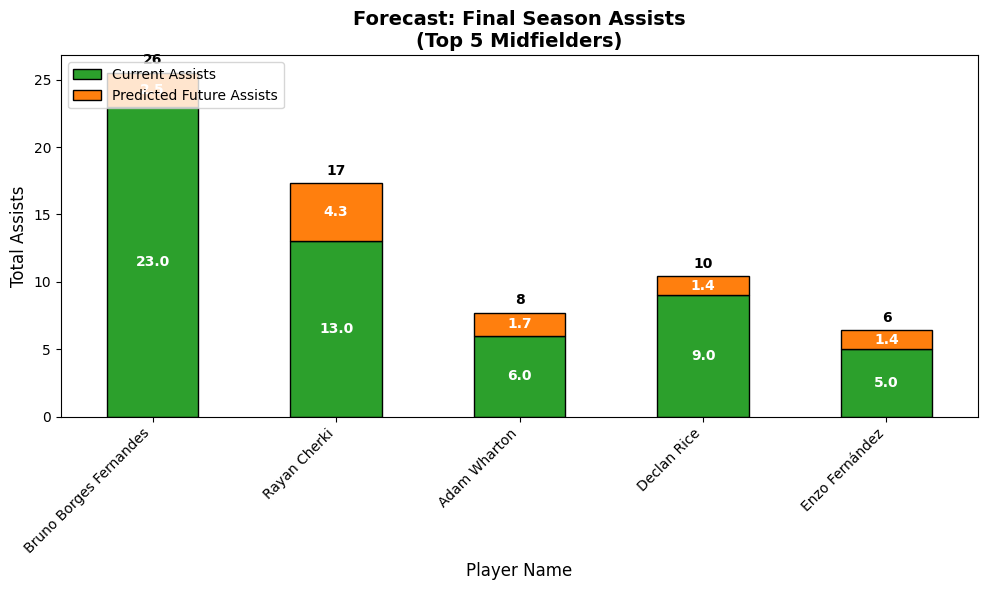


End of Season Forecast: Forwards - Goals
----------------------------------------------------------------------
                     Player Name  Current Goals  ML Rate (Per Game)  Predicted Next 8 Games  PREDICTED FINAL TOTAL
                  Erling Haaland             27                0.74                    5.89                     33
Igor Thiago Nascimento Rodrigues             22                0.59                    4.75                     27
   João Pedro Junqueira de Jesus             15                0.51                    4.11                     19
                 Viktor Gyökeres             14                0.54                    4.35                     18
                   Ollie Watkins             14                0.48                    3.82                     18


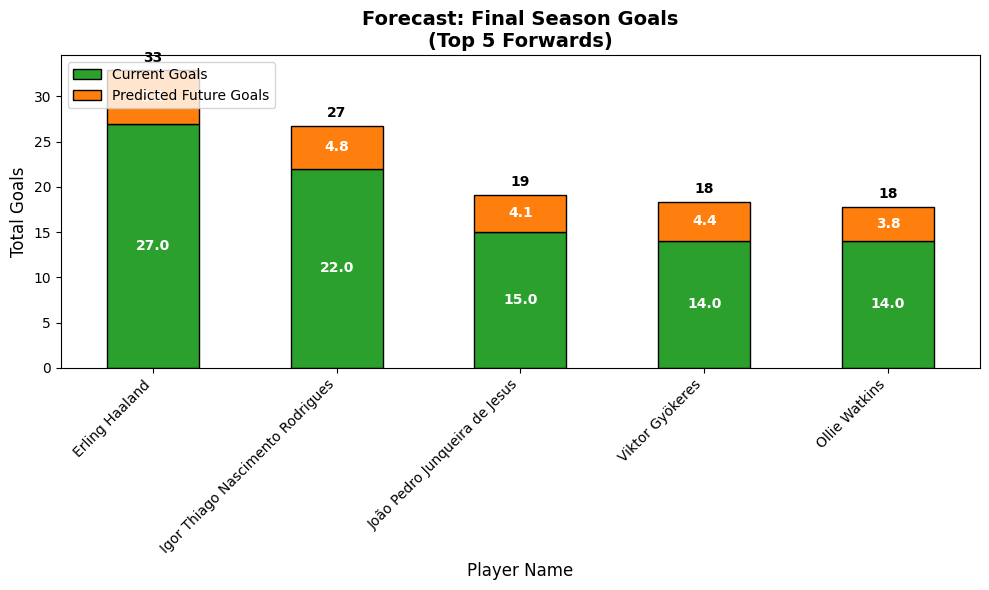


End of Season Forecast: Defenders - CBI (Clearances/Blocks/Int)
----------------------------------------------------------------------
        Player Name  Current CBI (Clearances/Blocks/Int)  ML Rate (Per Game)  Predicted Next 8 Games  PREDICTED FINAL TOTAL
Marcos Senesi Barón                                  352                9.32                   74.59                    427
    Virgil van Dijk                                  323                8.35                   66.77                    390
    James Tarkowski                                  316                8.83                   70.63                    387
    Maxence Lacroix                                  310                8.82                   70.57                    381
      Maxime Estève                                  290                8.69                   69.51                    360


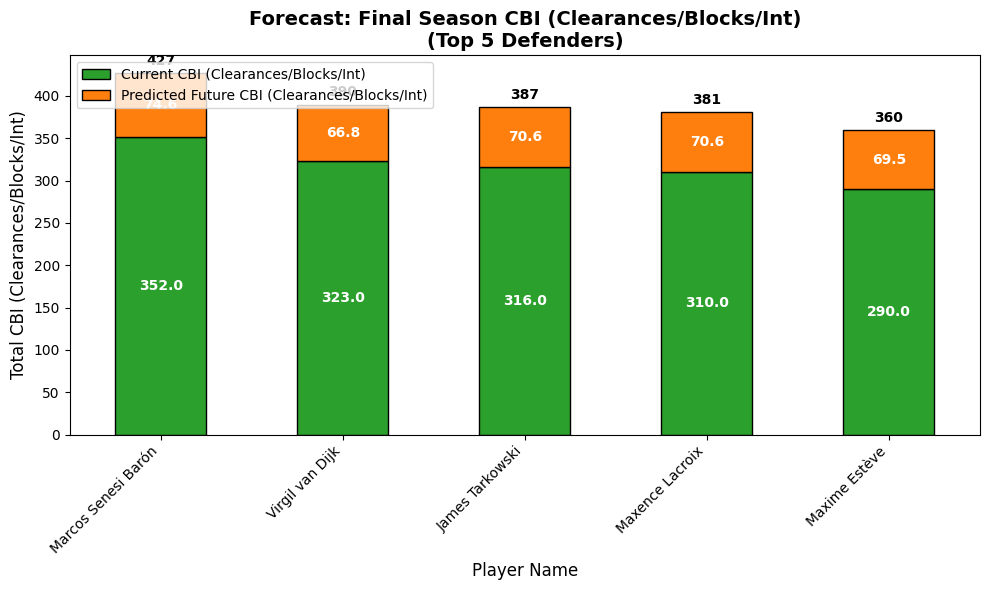


End of Season Forecast: Goalkeepers - Saves
----------------------------------------------------------------------
      Player Name  Current Saves  ML Rate (Per Game)  Predicted Next 8 Games  PREDICTED FINAL TOTAL
  Martin Dúbravka            127                3.30                   26.44                    153
      Robin Roefs            107                2.87                   22.95                    130
   Đorđe Petrović            106                2.79                   22.33                    128
Caoimhín Kelleher            102                2.81                   22.44                    124
  Bart Verbruggen            101                2.68                   21.47                    122


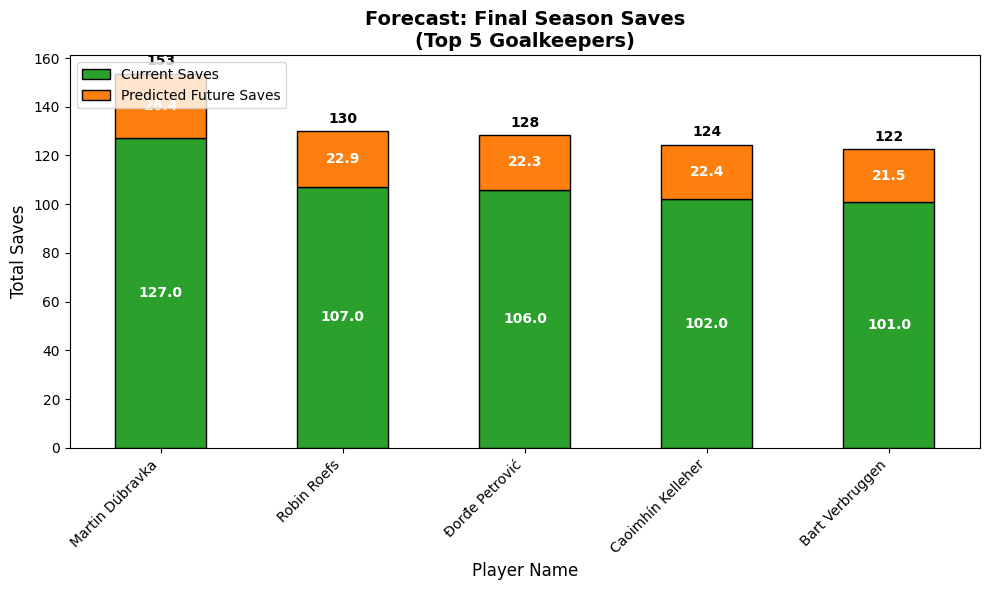

In [12]:
def forecast_end_of_season(df, features, target_col, sort_metric, position_title, target_name, games_left=8):

    X = df[features]
    y = df[target_col]

    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(x_train, y_train)

    top_5 = df.nlargest(5, sort_metric).copy()
    X_top_5 = top_5[features]

    top_5_predictions = model.predict(X_top_5)

    matches_played = top_5['minutes'] / 90
    ml_rate_per_game = top_5_predictions / matches_played
    future_stats = ml_rate_per_game * games_left
    final_total = top_5[target_col] + future_stats

    results = pd.DataFrame({
        'Player Name': top_5['player_name'].values,
        f'Current {target_name}': top_5[target_col].values,
        'ML Rate (Per Game)': np.round(ml_rate_per_game.values, 2),
        f'Predicted Next {games_left} Games': np.round(future_stats.values, 2),
        'PREDICTED FINAL TOTAL': np.round(final_total.values, 0).astype(int)
    })

    print(f"\nEnd of Season Forecast: {position_title} - {target_name}")
    print("-" * 70)
    print(results.to_string(index=False))

    plot_data = results.set_index('Player Name')[
        [f'Current {target_name}', f'Predicted Next {games_left} Games']]

    plt.figure(figsize=(10, 6))
    ax = plot_data.plot(kind='bar', stacked=True, color=[
                        '#2ca02c', '#ff7f0e'], ax=plt.gca(), edgecolor='black')

    plt.title(
        f'Forecast: Final Season {target_name}\n(Top 5 {position_title})', fontsize=14, fontweight='bold')
    plt.xlabel('Player Name', fontsize=12)
    plt.ylabel(f'Total {target_name}', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend([f'Current {target_name}',
               f'Predicted Future {target_name}'], loc='upper left')

    for container in ax.containers:
        ax.bar_label(container, label_type='center',
                     color='white', fontweight='bold', fmt='%.1f')

    ax.bar_label(ax.containers[-1], label_type='edge',
                 color='black', fontweight='bold', fmt='%.0f', padding=4)

    plt.tight_layout()
    plt.show()



def forecast_end_of_season(df, features, target_col, sort_metric, position_title, target_name, games_left=8):

    X = df[features]
    y = df[target_col]

    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(x_train, y_train)

    top_5 = df.nlargest(5, sort_metric).copy()
    X_top_5 = top_5[features]

    top_5_predictions = model.predict(X_top_5)

    matches_played = top_5['minutes'] / 90
    ml_rate_per_game = top_5_predictions / matches_played
    future_stats = ml_rate_per_game * games_left
    final_total = top_5[target_col] + future_stats

    results = pd.DataFrame({
        'Player Name': top_5['player_name'].values,
        f'Current {target_name}': top_5[target_col].values,
        'ML Rate (Per Game)': np.round(ml_rate_per_game.values, 2),
        f'Predicted Next {games_left} Games': np.round(future_stats.values, 2),
        'PREDICTED FINAL TOTAL': np.round(final_total.values, 0).astype(int)
    })

    print(f"\nEnd of Season Forecast: {position_title} - {target_name}")
    print("-" * 70)
    print(results.to_string(index=False))

    plot_data = results.set_index('Player Name')[
        [f'Current {target_name}', f'Predicted Next {games_left} Games']]

    plt.figure(figsize=(10, 6))
    ax = plot_data.plot(kind='bar', stacked=True, color=[
                        '#2ca02c', '#ff7f0e'], ax=plt.gca(), edgecolor='black')

    plt.title(
        f'Forecast: Final Season {target_name}\n(Top 5 {position_title})', fontsize=14, fontweight='bold')
    plt.xlabel('Player Name', fontsize=12)
    plt.ylabel(f'Total {target_name}', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend([f'Current {target_name}',
               f'Predicted Future {target_name}'], loc='upper left')

    for container in ax.containers:
        ax.bar_label(container, label_type='center',
                     color='white', fontweight='bold', fmt='%.1f')

    ax.bar_label(ax.containers[-1], label_type='edge',
                 color='black', fontweight='bold', fmt='%.0f', padding=4)

    plt.tight_layout()
    plt.show()


forecast_end_of_season(
    df=MF_stat,
    features=['expected_assists', 'creativity', 'influence'],
    target_col='assists',
    sort_metric='expected_assists',
    position_title='Midfielders',
    target_name='Assists'
)

forecast_end_of_season(
    df=FWD_stat,
    features=['threat', 'expected_goal_involvements', 'expected_goals'],
    target_col='goals_scored',
    sort_metric='goals_scored',
    position_title='Forwards',
    target_name='Goals'
)

forecast_end_of_season(
    df=Def_stat,
    features=['defensive_contribution', 'influence', 'minutes'],
    target_col='clearances_blocks_interceptions',
    sort_metric='clearances_blocks_interceptions',
    position_title='Defenders',
    target_name='CBI (Clearances/Blocks/Int)'
)

forecast_end_of_season(
    df=GK_stat,
    features=['expected_goals_conceded', 'minutes'],
    target_col='saves',
    sort_metric='saves',
    position_title='Goalkeepers',
    target_name='Saves'
)


In [13]:
def predict_player(player_name, games_left=8):
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    import numpy as np

    position_config = {
        'MID': {
            'df': MF_stat,
            'features': ['expected_assists', 'creativity', 'influence'],
            'targets': [('assists', 'Assists'), ('expected_goal_involvements', 'xGI')]
        },
        'FWD': {
            'df': FWD_stat,
            'features': ['threat', 'expected_goal_involvements', 'expected_goals'],
            'targets': [('goals_scored', 'Goals'), ('expected_goals', 'xG')]
        },
        'DEF': {
            'df': Def_stat,
            'features': ['defensive_contribution', 'influence', 'minutes'],
            'targets': [('clearances_blocks_interceptions', 'Clearances/Blocks/Int'), ('clean_sheets', 'Clean Sheets')]
        },
        'GKP': {
            'df': GK_stat,
            'features': ['expected_goals_conceded', 'minutes'],
            'targets': [('saves', 'Saves'), ('clean_sheets', 'Clean Sheets')]
        },
    }

    player_row = None
    player_position = None
    for pos, cfg in position_config.items():
        match = cfg['df'][cfg['df']['player_name'].str.lower() == player_name.lower()]
        if not match.empty:
            player_row = match.iloc[0]
            player_position = pos
            break

    if player_row is None:
        close = []
        for pos, cfg in position_config.items():
            names = cfg['df']['player_name'].str.lower()
            hits = cfg['df'][names.str.contains(player_name.lower(), na=False)]['player_name'].tolist()
            close += hits
        print(f"Player '{player_name}' not found.")
        if close:
            print(f"Did you mean: {close[:5]}")
        return

    cfg = position_config[player_position]
    matches_played = player_row['minutes'] / 90

    print(f"\n{'='*55}")
    print(f"  Player : {player_row['player_name']}")
    print(f"  Club   : {player_row['club_name']}")
    print(f"  Pos    : {player_position}")
    print(f"  Apps   : {matches_played:.1f}  |  Games left: {games_left}")
    print(f"{'='*55}")

    for target_col, target_name in cfg['targets']:
        if target_col not in cfg['df'].columns:
            continue
        df = cfg['df']
        X = df[cfg['features']]
        y = df[target_col]
        x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(x_train, y_train)
        player_features = np.array([[player_row[f] for f in cfg['features']]])
        predicted_pace = model.predict(player_features)[0]
        rate = predicted_pace / matches_played if matches_played > 0 else 0
        predicted_future = rate * games_left
        current = player_row[target_col]
        final = current + predicted_future
        print(f"  {target_name}:")
        print(f"    Current total         : {current:.0f}")
        print(f"    Rate per game         : {rate:.2f}")
        print(f"    Predicted next {games_left}GW  : +{predicted_future:.1f}")
        print(f"    Predicted final total : {final:.0f}")
        print()


predict_player("mohamed Salah")



  Player : Mohamed Salah
  Club   : Liverpool
  Pos    : MID
  Apps   : 23.0  |  Games left: 8


d:\DS Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


  Assists:
    Current total         : 6
    Rate per game         : 0.25
    Predicted next 8GW  : +2.0
    Predicted final total : 8

  xGI:
    Current total         : 13
    Rate per game         : 0.50
    Predicted next 8GW  : +4.0
    Predicted final total : 17



d:\DS Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [14]:
data[data['player_name'].str.contains('Salah', case=False)]['player_name'].tolist()

['Mohamed Salah']